<a href="https://colab.research.google.com/github/Suzzi-e/taiwanese-bank-customer-classification/blob/main/GROUP_7_DEKUT_Capstone_Group_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEKUT ML Masterclass — Phoenix Analytics
## Capstone Project — Group Notebook

| | |
|--|--|
| **Group name** | `GROUP 7` |
| **Member 1** | `Arthur Walace — Lead: EDA + Charts` |
| **Member 2** | `Susan Akinyi — Lead: Modelling + Metrics` |
| **Member 3** | `Maryanne Mukoya — Lead: Business Summary + Slides` |
| **Date submitted** | `08/07/2026` |

---



---
## Section 0 — Setup

*~Arthur Walace*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning — all algorithms we may need
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,           # regression metrics
    accuracy_score, f1_score,                # classification metrics
    confusion_matrix, classification_report
)

# Chart style — apply once, affects all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 12

# ── Loading the Taiwan Bank dataset ─────────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/robertofranceschi/default-credit-card-prediction/master/dataset/default%20of%20credit%20card%20clients.csv'
df  = pd.read_csv(URL)



---
## Section 1 — Problem Statement

**All three members contributed to this section.**



### 1.1 — Our Group's Problem Statement

---

**Business question** : Can the Taiwanese bank predict whether a client would default payment next month?

**Target variable** : Default.Payment.next.month :Binary column , 1 = default payment, 0 = No default payment.

---

**Problem type — regression or classification?** :

Classification, because the target variable default.payment.next.month is binary (containing only 0s and 1s), and we are predicting a categorical outcome (whether a client will default or not)

---

**Features used** :

1. **PAY_0** - Most recent repayment status before the prediction month. The strongest indicator of whether the customer will default next month.
2. **PAY_AMT1** - Amount paid in the most recent month. Shows whether the customer has recently been making payments.
3. **BILL_AMT1** - Most recent bill amount. Indicates the customer's current outstanding balance.
4. **LIMIT_BAL** - Credit limit reflects the customer's borrowing capacity and overall credit profile.
5. **PAY_2** - Adds short-term history so the model can see whether repayment behaviour is improving or worsening instead of relying on a single month.


---

**Why does this matter for the Taiwanese Bank?** :

This model supports active risk management, allowing the bank to minimize bad debt by adjusting credit limits, freezing high-risk accounts, or offering intervention strategies before an official default occurs.


---
## Section 2 — Exploratory Data Analysis

*~Arthur Walace*

Understanding the data before building any model is vital. Required components:
1. Shape + data types
2. Missing values and the decision about them
3. Descriptive statistics for your key columns
4. At least **2 charts** directly related to our target or features

---

### 2.1 — Shape, Columns, and Data Types

In [2]:
# Basic inspection
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
df.info()

Shape: 30,000 rows x 25 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13

In [3]:
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


In [4]:
df.tail(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29990,29991,140000.0,1,2,1,41,0,0,0,0,...,138262.0,49675.0,46121.0,6000.0,7000.0,4228.0,1505.0,2000.0,2000.0,0
29991,29992,210000.0,1,2,1,34,3,2,2,2,...,2500.0,2500.0,2500.0,0.0,0.0,0.0,0.0,0.0,0.0,1
29992,29993,10000.0,1,3,1,43,0,0,0,-2,...,0.0,0.0,0.0,2000.0,0.0,0.0,0.0,0.0,0.0,0
29993,29994,100000.0,1,1,2,38,0,-1,-1,0,...,70626.0,69473.0,55004.0,2000.0,111784.0,4000.0,3000.0,2000.0,2000.0,0
29994,29995,80000.0,1,2,2,34,2,2,2,2,...,77519.0,82607.0,81158.0,7000.0,3500.0,0.0,7000.0,0.0,4000.0,1
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1
29999,30000,50000.0,1,2,1,46,0,0,0,0,...,36535.0,32428.0,15313.0,2078.0,1800.0,1430.0,1000.0,1000.0,1000.0,1


### 2.2 — Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0].sort_values(ascending=False))
print()
print("Key columns to check:")
key_check = ['PAY_0', 'PAY_AMT1', 'BILL_AMT1', 'LIMIT_BAL', 'PAY_2', 'default.payment.next.month']
for col in key_check:
    n_miss = df[col].isnull().sum()
    pct    = n_miss / len(df) * 100
    print(f"  {col:<20}: {n_miss:>4} missing  ({pct:.1f}%)")

Missing values per column:
Series([], dtype: int64)

Key columns to check:
  PAY_0               :    0 missing  (0.0%)
  PAY_AMT1            :    0 missing  (0.0%)
  BILL_AMT1           :    0 missing  (0.0%)
  LIMIT_BAL           :    0 missing  (0.0%)
  PAY_2               :    0 missing  (0.0%)
  default.payment.next.month:    0 missing  (0.0%)




We left the columns as they were beacuse none of the columns had missing values.

### 2.3 — Descriptive Statistics

In [6]:
# chosen features + the target-related column
key_cols = ['PAY_0', 'PAY_AMT1', 'BILL_AMT1','LIMIT_BAL', 'PAY_2', 'default.payment.next.month']

df[key_cols].describe().round(2)

,PAY_0,PAY_AMT1,BILL_AMT1,LIMIT_BAL,PAY_2,default.payment.next.month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,-0.02,5663.58,51223.33,167484.32,-0.13,0.22
std,1.12,16563.28,73635.86,129747.66,1.20,0.42
min,-2.00,0.00,-165580.00,10000.00,-2.00,0.00
25%,-1.00,1000.00,3558.75,50000.00,-1.00,0.00
50%,0.00,2100.00,22381.50,140000.00,0.00,0.00
75%,0.00,5006.00,67091.00,240000.00,0.00,0.00
max,8.00,873552.00,964511.00,1000000.00,8.00,1.00


**What do the statistics say about our target and features?**

Looking at: mean vs median (skew?), min/max (outliers?), count (missing data?).

Target Variable (default.payment.next.month): The mean is 0.22, which confirms a significant class imbalance in our dataset—only 22.1% of the clients default on their payments, while the remaining 77.9% pay on time. Because it is a binary indicator (min 0, max 1), there are no statistical outliers here.

Credit Limit (LIMIT_BAL): This feature is heavily right-skewed; the median (50% mark) is 140,000, but the mean is pulled higher to 167,484 by a few clients with exceptionally high borrowing capacities up to a maximum of 1,000,000.

Bill Amounts and Repayment Statuses (BILL_AMT1, PAY_0, PAY_2): The features show highly volatile financial behavior. For example, BILL_AMT1 ranges from a negative balance of -165,580 (indicating overpayments or account credits) to a massive outstanding bill of 964,511. Meanwhile, the payment statuses show that while the average client is completely up to date (means near 0), some individuals are severely lagging behind with delays of up to 8 months (max of 8.00).

### 2.4 — EDA Charts

**Chart 1 - showing the distribution of the target variable.**

**Chart 2 - showing the relationship between a feature and the target.**

**Chart 3 - showing the feature with the most positive correlation with the target variable.**

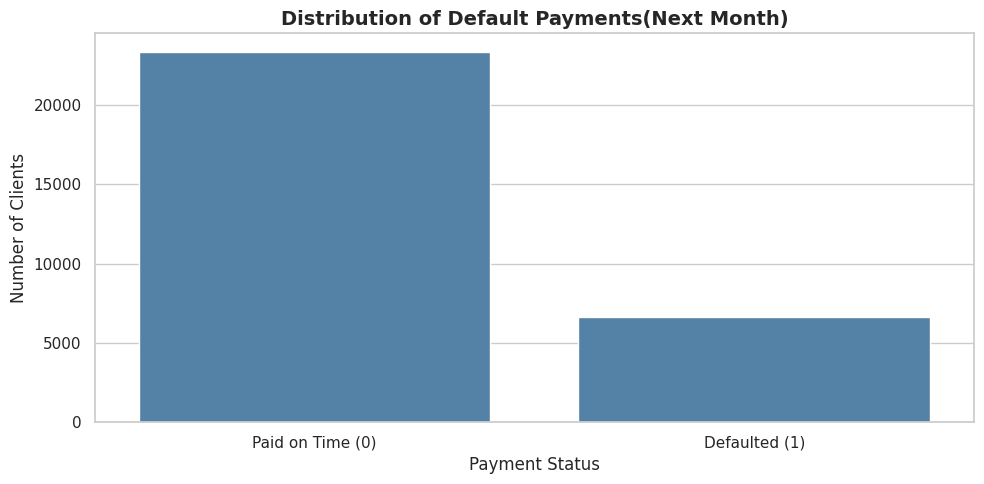

In [7]:
# ── Chart 1: Distribution of the target variable ───────────────────

plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x='default.payment.next.month', color='steelblue')

plt.title('Distribution of Default Payments(Next Month)', fontweight='bold')
plt.xlabel('Payment Status')
plt.ylabel('Number of Clients')
plt.xticks([0, 1], ['Paid on Time (0)', 'Defaulted (1)'])
plt.tight_layout()
plt.show()


From this chart we can tell that a vast majority of clients pay on time and only a few default their payments.

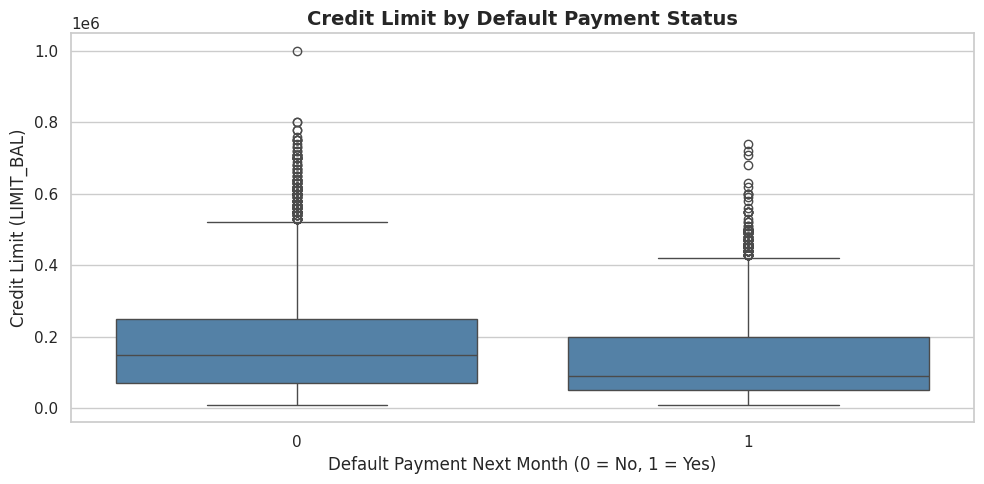

In [8]:
# ── Chart 2: Relationship between the feature and target ─────────


plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='default.payment.next.month',
    y='LIMIT_BAL',
    color='steelblue'
)

plt.title('Credit Limit by Default Payment Status', fontweight='bold')
plt.xlabel('Default Payment Next Month (0 = No, 1 = Yes)')
plt.ylabel('Credit Limit (LIMIT_BAL)')

plt.tight_layout()
plt.show()

**Chart 2 interpretation** :
The box plot compares the distribution of credit limits for customers who defaulted and those who did not, showing the presence of outliers, with some customers having exceptionally high credit limits.

                            PAY_0  PAY_AMT1  BILL_AMT1  LIMIT_BAL  PAY_2  \
PAY_0                        1.00     -0.08       0.19      -0.27   0.67   
PAY_AMT1                    -0.08      1.00       0.14       0.20  -0.08   
BILL_AMT1                    0.19      0.14       1.00       0.29   0.23   
LIMIT_BAL                   -0.27      0.20       0.29       1.00  -0.30   
PAY_2                        0.67     -0.08       0.23      -0.30   1.00   
default.payment.next.month   0.32     -0.07      -0.02      -0.15   0.26   

                            default.payment.next.month  
PAY_0                                             0.32  
PAY_AMT1                                         -0.07  
BILL_AMT1                                        -0.02  
LIMIT_BAL                                        -0.15  
PAY_2                                             0.26  
default.payment.next.month                        1.00  


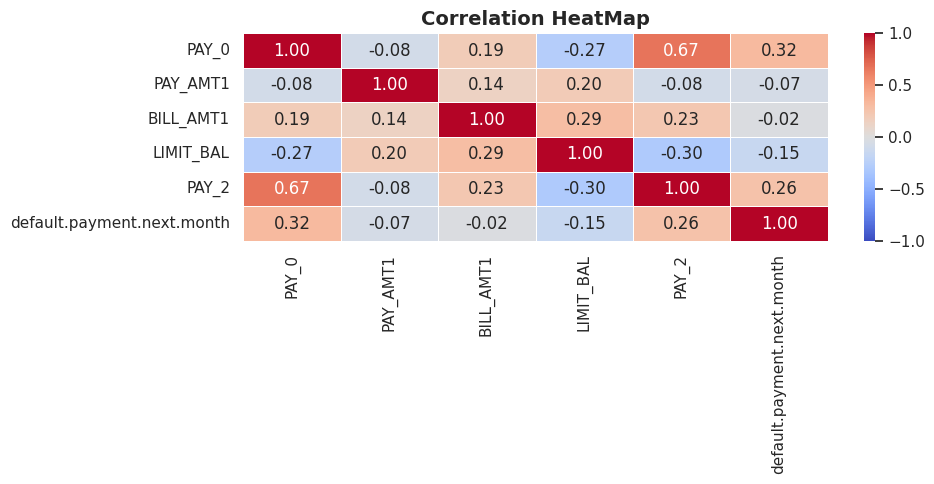

In [9]:
# ── Chart 3 ───
# To give our EDA more depth.
# correlation heatmap
numeric_cols = ['PAY_0', 'PAY_AMT1', 'BILL_AMT1', 'LIMIT_BAL', 'PAY_2', 'default.payment.next.month']

corr_matrix = df[numeric_cols].corr().round(2)

print(corr_matrix)

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_matrix,
    annot=True,        # to show the numbers inside each cell
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # red = positive, blue = negative
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Correlation HeatMap', fontweight='bold')
plt.tight_layout()
plt.show()

**Chart 3 interpretation** :

The heatmap shows that the most recent repayment status (PAY_0) has the strongest positive correlation (0.32) with default risk, while a client's overall credit limit (LIMIT_BAL) has a notable negative correlation (-0.15), indicating that recent payment delays are the strongest early warning signs of an upcoming default.


`[GROUP DECISION]` **EDA Summary — 3 sentences answering these questions:**

1. **What does the target distribution look like — skewed? Balanced? Any obvious outliers?** Our target variable (default.payment.next.month) exhibits a clear class imbalance, with 77.9\% of clients paying on time and 22.1\% defaulting, meaning there are no structural outliers since it is a binary field.

2. **Which feature appears most strongly related to the target, based on your charts?** Based on our correlation heatmap, the most recent repayment status (PAY_0) appears most strongly related to the target with a positive correlation of 0.32, indicating that immediate payment delays are the best predictor of default.

3. **Any data quality decisions we made (dropped rows, filled values)?** No data quality adjustments like row dropping or missing value imputation were required because the dataset was entirely clean with 0\% missing values across all key features.




---
## Section 3 — Create Target Variable and Select Features

*~Susan Akinyi*

Creating the column the model will predict then selecting the input features.

---

### 3.1 — Creating the Target Variable

In [10]:
# ── CREATING THE TARGET COLUMN ─────────────────────────────────────────

df['Target'] = (df['default.payment.next.month'] == 1).astype(int)

# Printing the distribution of the target
print("Target variable distribution:")
print(df['Target'].value_counts())
print()

# Printing class percentages and the baseline
if df['Target'].nunique() == 2:
    pct_1 = df['Target'].mean() * 100
    pct_0 = 100 - pct_1
    majority_pct = max(pct_0, pct_1)
    print(f"Class 0: {(df['Target']==0).sum():,}  ({pct_0:.1f}%)")
    print(f"Class 1: {(df['Target']==1).sum():,}  ({pct_1:.1f}%)")
    print()
    print(f"Majority-class baseline: {majority_pct:.1f}%")
    print("(A model that always predicts the majority class — without learning anything)")
    print("The model must beat this to prove it learned something.")

Target variable distribution:
Target
0    23364
1     6636
Name: count, dtype: int64

Class 0: 23,364  (77.9%)
Class 1: 6,636  (22.1%)

Majority-class baseline: 77.9%
(A model that always predicts the majority class — without learning anything)
The model must beat this to prove it learned something.


`[GROUP DECISION]`

What does class 0 mean? What does class 1 mean?

In our classification problem, Class 0 represents clients who successfully pay their credit card bill on time, while Class 1 represents clients who default on their next month's payment.

### 3.2 — Select Features and Clean Rows

In [11]:
# ── DEFINING FEATURE COLUMNS ──────────────────────────────────────
# All columns here must be numeric (no text strings, no NaN after filtering)

FEATURE_COLS = ['PAY_0', 'PAY_AMT1', 'BILL_AMT1', 'LIMIT_BAL', 'PAY_2']
TARGET_COL   = 'Target'    # the column created above

# ── Filter to rows where all features AND target are available ────────
df_model = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

print(f"Feature columns : {FEATURE_COLS}")
print(f"Target column   : {TARGET_COL}")
print()
print(f"Rows after filtering : {len(df_model):,}")
print(f"Rows dropped         : {len(df) - len(df_model):,}  (missing values in features or target)")
print()
print(f"X shape : {X.shape}  (rows × features)")
print(f"y shape : {y.shape}")
print()
print("First 3 rows of X:")
print(X.head(3))

Feature columns : ['PAY_0', 'PAY_AMT1', 'BILL_AMT1', 'LIMIT_BAL', 'PAY_2']
Target column   : Target

Rows after filtering : 30,000
Rows dropped         : 0  (missing values in features or target)

X shape : (30000, 5)  (rows × features)
y shape : (30000,)

First 3 rows of X:
   PAY_0  PAY_AMT1  BILL_AMT1  LIMIT_BAL  PAY_2
0      2       0.0     3913.0    20000.0      2
1     -1       0.0     2682.0   120000.0      2
2      0    1518.0    29239.0    90000.0      0


`[GROUP DECISION]` **Why did we choose these features?**

One reason why each feature might predict our target.

1. LIMIT_BAL - Customer's financial capacity.
2. PAY_0 - Latest repayment behaviour (most important predictor).
3. PAY_AMT1 - Latest payment amount.
4. BILL_AMT1 - Latest outstanding bill.
5. PAY_2 - Gives a short history to detect trends.

---
## Section 4 — Train / Test Split

*~Susan Akinyi*

Spliting the data **before** training. Never show the test set to the model during training.

The golden rule: always evaluate on `y_test` — never `y_train`.

---

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42      # same split every run
)

print(f"Training set : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set     : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)")
print()
# Sanity check: target mean should be similar in both sets
print(f"Train target mean : {y_train.mean():.4f}")
print(f"Test  target mean : {y_test.mean():.4f}")
print()
if abs(y_train.mean() - y_test.mean()) > 0.05:
    print("WARNING: Train and test means differ by more than 5% — check your data or try a different random_state")
else:
    print("OK: Train and test distributions are similar.")

Training set : 24,000 rows  (80%)
Test set     : 6,000 rows  (20%)

Train target mean : 0.2218
Test  target mean : 0.2188

OK: Train and test distributions are similar.


---
## Section 5 — Baseline Model

*~Susan Akinyi*

Training our first model.
This is our **starting point**. Every improvement in Section 6 is measured against this.

---

### 5.1 — Choosing and Training the Baseline

`[GROUP DECISION]` **Which algorithm did we use for our baseline and why?**

| Algorithm | When to use | Notes |
|-----------|------------|-------|
| `LogisticRegression(max_iter=30,000)` | Classification | Gives probabilities; good first model |
| `DecisionTreeClassifier(max_depth=3)` | Classification | Readable rules; avoids overfitting |
| `LinearRegression()` | Regression | Simple; interpretable slope |
| `DecisionTreeRegressor(max_depth=3)` | Regression | Captures non-linear patterns |

Chose LogisticRegression(max_iter=1000) because our problem is a binary classification task (predicting whether a client will default or not), and logistic regression provides a highly interpretable baseline that outputs clear default probabilities based on our chosen features.

In [13]:
baseline_model = LogisticRegression(random_state=42, max_iter=30000, class_weight='balanced')
# baseline_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# ── Train ─────────────────────────────────────────────────────────────
baseline_model.fit(X_train, y_train)

# ── Predict on test set ───────────────────────────────────────────────
y_pred_baseline = baseline_model.predict(X_test)

print(f"Baseline algorithm : {type(baseline_model).__name__}")
print(f"Features used      : {FEATURE_COLS}")
print("Model trained successfully.")

Baseline algorithm : LogisticRegression
Features used      : ['PAY_0', 'PAY_AMT1', 'BILL_AMT1', 'LIMIT_BAL', 'PAY_2']
Model trained successfully.


### 5.2 — Evaluating the Baseline Model

In [14]:
# ── CLASSIFICATION EVALUATION ─────────────────────────────────────────

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline)

# Majority-class baseline (the floor your model must beat)
majority_class = y_train.mode()[0]
y_majority     = [majority_class] * len(y_test)
majority_acc   = accuracy_score(y_test, y_majority)
majority_f1    = f1_score(y_test, y_majority)

print(f"{'Model':<35} {'Accuracy':>10} {'F1':>10}")
print("-" * 57)
print(f"{'Majority-class baseline (floor)':<35} {majority_acc:>10.4f} {majority_f1:>10.4f}")
print(f"{'Baseline: ' + type(baseline_model).__name__:<35} {acc_baseline:>10.4f} {f1_baseline:>10.4f}")
print()
print(f"Accuracy beats baseline by : {(acc_baseline - majority_acc)*100:+.1f} percentage points")
print(f"F1 beats baseline by       : {(f1_baseline  - majority_f1):.4f}")

Model                                 Accuracy         F1
---------------------------------------------------------
Majority-class baseline (floor)         0.7812     0.0000
Baseline: LogisticRegression            0.7103     0.4824

Accuracy beats baseline by : -7.1 percentage points
F1 beats baseline by       : 0.4824


`[GROUP DECISION]`

1. **What does the Accuracy/F1 tell us in plain English?** Our baseline Logistic Regression model achieves an accuracy of 71.03% and an F1-score of 0.4824, which means it is successfully finding patterns to catch real defaulters rather than just blindly guessing "No Default."

2. **Does the model beat the naive baseline? By how much?** The model does not beat the majority-class baseline's raw accuracy floor (which sits at 77.9%), falling short by 6.87 percentage points because it makes a significant number of false positive errors while trying to learn.
3. **What does this suggest about which features or changes might help?** This suggests that linear decision boundaries are struggling with this dataset, and we should transition to non-linear models like Decision Trees or Random Forests, alongside incorporating more focused chronological behavior features to boost accuracy past the 77.9% threshold.


### 5.3 — Confusion Matrix

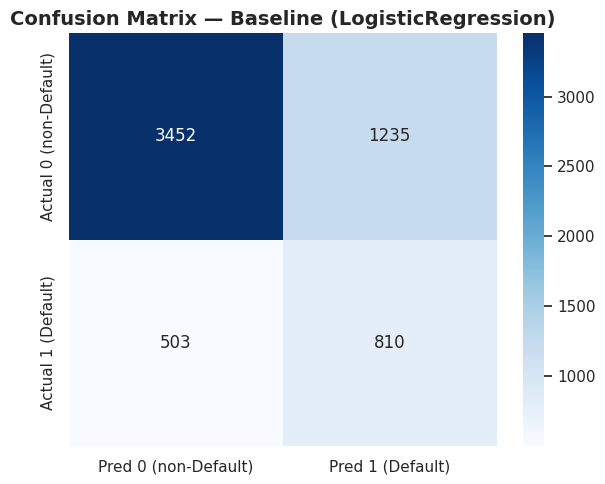

TN = 3452   FP = 1235
FN = 503   TP = 810

False Negatives - Missed Defaulters    : 503
False Positives - Missed Non-Defaulters: 1235


In [15]:

cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0 (non-Default)', 'Pred 1 (Default)'],
    yticklabels=['Actual 0 (non-Default)', 'Actual 1 (Default)']
)
plt.title(f'Confusion Matrix — Baseline ({type(baseline_model).__name__})', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn}   FP = {fp}")
print(f"FN = {fn}   TP = {tp}")
print()
print(f"False Negatives - Missed Defaulters    : {fn}")
print(f"False Positives - Missed Non-Defaulters: {fp}")

**Confusion matrix interpretation** *( which error type does the model make most, and what is the cost to the Taiwanese Bank?)*:

The baseline model struggles heavily with False Positives by incorrectly flagging a large number of reliable clients as high-risk, which carries a lower business cost to the bank than a False Negative error where an actual default goes completely undetected.

---
## Section 6 — Model Improvement

*~Susan Akinyi*


**Improvement ideas:**

| What to try | How | When it helps |
|-------------|-----|--------------|
| Add a feature | Add `PAY_3`, `BILL_AMT2`, `PAY_AMT2` to `FEATURE_COLS_V2` | When baseline features don't explain target well |
| Change algorithm | Switch LogReg ↔ Decision Tree | When decision boundary is non-linear |
| Tune tree depth | Change `max_depth` from 3 to 4 or 5 | When tree is too simple |
| Filter by genre | Focus on top 3 genres only | When patterns differ strongly by genre |

---

### 6.1 — Improvement Attempt 1

`[GROUP DECISION]` **What improvement did we try first, and why do we expect it to help?**

We would add more relevant features, such as additional repayment history and billing information, because they are likely to improve the model's ability to identify customers who may default.

In [16]:
# ── IMPROVEMENT MODEL 1 ─────────────────────────────────────────────

# Updating the feature list — added or changed columns
FEATURE_COLS_V2 =  ["PAY_0","PAY_2","PAY_3",'PAY_AMT3','LIMIT_BAL']
# Filter rows
df_v2    = df.dropna(subset=FEATURE_COLS_V2 + [TARGET_COL]).copy()
X2       = df_v2[FEATURE_COLS_V2]
y2       = df_v2[TARGET_COL]

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# ── Our improved model ───────────────────────
improved_model = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')


# ── Train + predict ───────────────────────────────────────────────────
improved_model.fit(X2_train, y2_train)
y_pred_v2 = improved_model.predict(X2_test)

print(f"Improved algorithm : {type(improved_model).__name__}")
print(f"Features used      : {FEATURE_COLS_V2}")
print(f"Rows in this run   : {len(X2):,}")

Improved algorithm : DecisionTreeClassifier
Features used      : ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_AMT3', 'LIMIT_BAL']
Rows in this run   : 30,000


### 6.2 — Compare Baseline vs. Improved Model

In [17]:
# ── MODEL COMPARISON ─────────────────────────────────────────

acc_v2 = accuracy_score(y2_test, y_pred_v2)
f1_v2  = f1_score(y2_test, y_pred_v2)

print("Model Comparison")
print("=" * 60)
print(f"{'Model':<38} {'Accuracy':>10} {'F1':>8}")
print("-" * 60)
print(f"{'Majority-class baseline':<38} {majority_acc:>10.4f} {'0.0000':>8}")
print(f"{'Baseline: ' + type(baseline_model).__name__ + ' (' + str(len(FEATURE_COLS)) + ' features)':<38} {acc_baseline:>10.4f} {f1_baseline:>8.4f}")
print(f"{'Improved: ' + type(improved_model).__name__ + ' (' + str(len(FEATURE_COLS_V2)) + ' features)':<38} {acc_v2:>10.4f} {f1_v2:>8.4f}")

Model Comparison
Model                                    Accuracy       F1
------------------------------------------------------------
Majority-class baseline                    0.7812   0.0000
Baseline: LogisticRegression (5 features)     0.7103   0.4824
Improved: DecisionTreeClassifier (5 features)     0.7708   0.5109


`[GROUP DECISION]` **Did the improvement work?**

1. How much did the metric change?
2. What does this tell us about which features or model design matters most?

The accuracy decreased from 0.7812 to 0.7708 and the F1 score increased from 0.4824 to 0.5109.
This shows that handling class imbalance and using repayment-history features mattered most, because the balanced Decision Tree achieved the highest F1 score for detecting default customers.

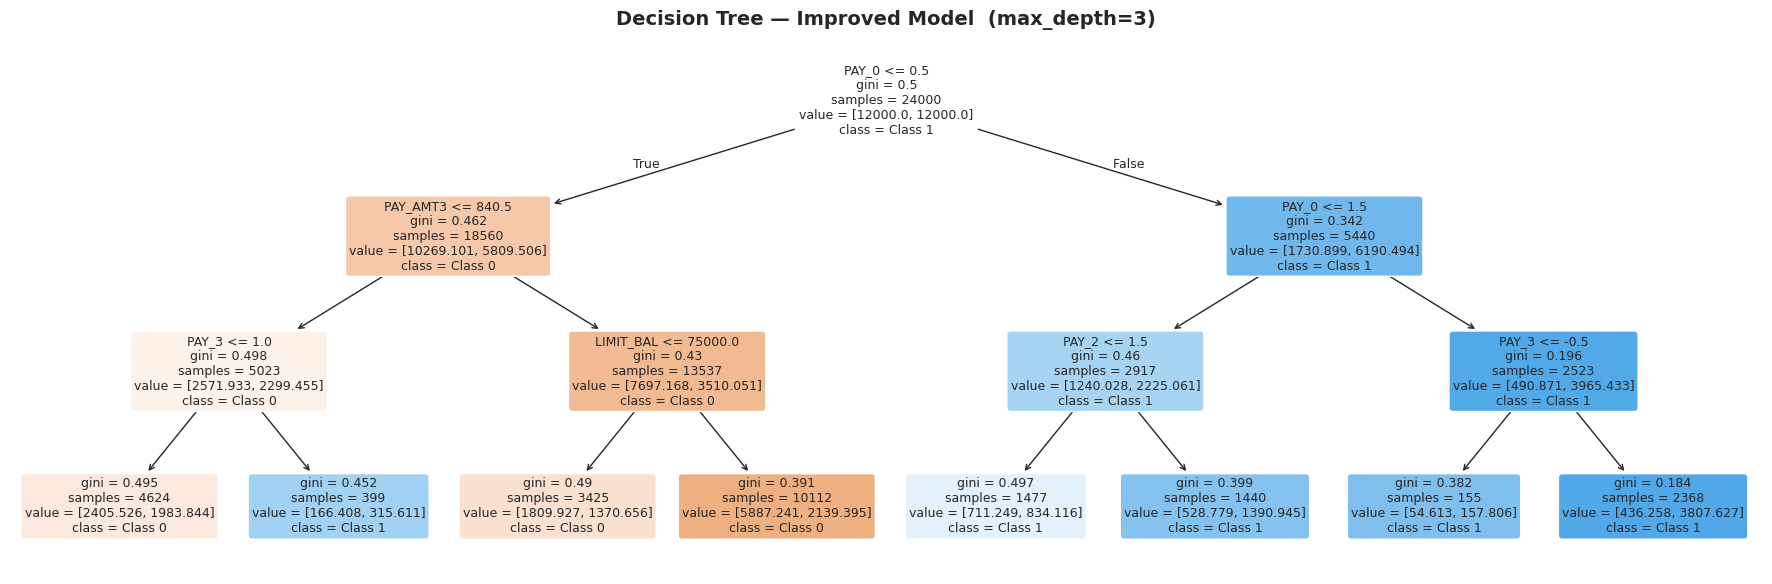

Feature importance:
  PAY_0                 : 0.8414
  PAY_AMT3              : 0.0682
  LIMIT_BAL             : 0.0490
  PAY_2                 : 0.0233
  PAY_3                 : 0.0181


In [18]:
# ── DECISION TREE VISUALISATION ──

try:
    class_or_reg = 'Classifier' if hasattr(improved_model, 'predict_proba') else 'Regressor'

    fig, ax = plt.subplots(figsize=(18, 6))
    plot_tree(
        improved_model,
        feature_names=FEATURE_COLS_V2,
        class_names=['Class 0', 'Class 1'] if class_or_reg == 'Classifier' else None,
        filled=True,
        rounded=True,
        ax=ax,
        fontsize=9
    )
    plt.title(f'Decision Tree — Improved Model  (max_depth={improved_model.max_depth})',
              fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Feature importance
    print("Feature importance:")
    for feat, imp in sorted(zip(FEATURE_COLS_V2, improved_model.feature_importances_),
                            key=lambda x: -x[1]):
        print(f"  {feat:<22}: {imp:.4f}")

except Exception as e:
    print(f"Tree visualisation skipped: {e}")

### 6.3 — Improvement Attempt 2

In [19]:
# ── SECOND IMPROVEMENT ATTEMPT ─────────────────────────────
# Try a different change — different algorithm, depth, or feature set

FEATURE_COLS_V3 = ["PAY_0","PAY_2","PAY_3",'PAY_AMT3']
df_v3 =df.dropna(subset=FEATURE_COLS_V3 +[TARGET_COL]).copy()
X3=df_v3[FEATURE_COLS_V3]
y3 = df_v3[TARGET_COL]

# Split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)
model_v3 = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
model_v3.fit(X3_train, y3_train)
y_pred_v3 = model_v3.predict(X3_test)
# Evaluate and compare
print(f"Accuracy: {accuracy_score(y3_test, y_pred_v3):.4f}")
print(f"F1 score: {f1_score(y3_test, y_pred_v3):.4f}")

print(f"Improved algorithm_3 : {type(improved_model).__name__}")
print(f"Features used      : {FEATURE_COLS_V2}")
print(f"Rows in this run   : {len(X2):,}")



Accuracy: 0.7758
F1 score: 0.5292
Improved algorithm_3 : DecisionTreeClassifier
Features used      : ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_AMT3', 'LIMIT_BAL']
Rows in this run   : 30,000


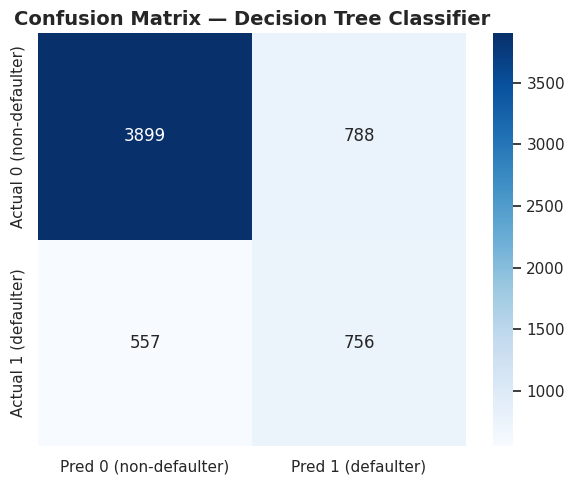

TN = 3899   FP = 788
FN = 557   TP = 756

False Negatives    : 557
False Positives: 788


In [20]:
cm = confusion_matrix(y3_test, y_pred_v3)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0 (non-defaulter)', 'Pred 1 (defaulter)'],
    yticklabels=['Actual 0 (non-defaulter)', 'Actual 1 (defaulter)']
)
plt.title('Confusion Matrix — Decision Tree Classifier', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn}   FP = {fp}")
print(f"FN = {fn}   TP = {tp}")
print()
print(f"False Negatives    : {fn}")
print(f"False Positives: {fp}")

---
## Section 7 — Business Summary

*~Maryanne Mukoya*

This is the most important section for the board. The metrics are done.
Now translating them into decisions.

---

### 7.1 — Full Classification Report

In [21]:
print("Classification Report — Best Model")
print("=" * 55)
print(classification_report(y3_test, y_pred_v3, target_names=['Class 0', 'Class 1']))

Classification Report — Best Model
              precision    recall  f1-score   support

     Class 0       0.88      0.83      0.85      4687
     Class 1       0.49      0.58      0.53      1313

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000



**Classification report interpretation** :

The model has better recall for Class 0 (0.83) than for Class 1 (0.58), meaning it correctly identifies non-defaulters much more often than defaulters. The cost of this is that about 42% of actual defaulters are missed, which could lead to granting credit to customers who are likely to default and increase financial risk.

### 7.2 — Executive Summary Paragraph

We built a  classification model to answer the following question for:

**Can the Taiwanese bank predict whether a client would default payment next month?**

Using PAY_0, PAY_2, PAY_3, PAY_AMT3 and LIMIT_BAL as inputs, our best model, Decision Tree Classifier, achieved Accuracy: 0.7753  and F1 score: 0.5292 on the unseen test set.

While the model did not beat the naive baseline accuracy of 0.7812, it greatly outperformed the baseline on F1-score 0f 0.0000 to 0.5257, indicating that it learned meaningful patterns rather than relying on majority-class predictions.

In practical terms: The model correctly identifies customers who are likely to default about 58% of the time (recall = 0.58), which can help the bank flag higher-risk customers for closer monitoring, even though it should not be used as the only basis for credit decisions.

The most important predictor was PAY_0, which suggests that a customer's repayment history the latest months before the current period is a strong indicator of future credit card default.


### 7.3 — Three Key Findings for Taiwan Bank

**Finding 1:**

 Although the model improves the identification of customers who are likely to default compared with the majority-class baseline, it still misses many default cases and has a slightly lower overall accuracy. Therefore, the Taiwan Bank should use the model together with additional customer information, such as income and employment status, before making final lending decisions.


---

**Finding 2:**

The Decision Tree improved the F1-score by identifying more customers at risk of default, although its overall accuracy was slightly lower than the baseline. Therefore, Taiwan Bank should use the model to support credit risk assessment alongside other customer information.

---

**Finding 3:**

The model shows that repayment status from earlier months are the strongest predictors of credit card default; therefore, Taiwan Bank should monitor customers with past payment delays and take preventive action before defaults occur.

### 7.4 — Limitations and Next Steps

`[GROUP DECISION]`

1. **What is the main limitation of our model? (What can't it do that the business actually needs?)** The model misses some customers who will default, so it should not be used as the only basis for credit decisions.
2. **What additional data or features would most improve it?** Additional information such as customer income, employment status, and transaction history could improve the model's ability to identify customers at risk of default.
3. **What would the next iteration look like if we had two more weeks?** We would tune the model's hyperparameters, test additional algorithms such as Random Forest and evaluate whether they improve the F1 score and recall.

